# Merton Share

L'applicazione pratica della formula , nota come **Merton Share** o quota di Merton, rappresenta il pilastro dell'allocazione ottima tra un'attività rischiosa e una priva di rischio. Per un asset allocator, questo modello trasforma l'input soggettivo (avversione al rischio) e gli input statistici (rendimento atteso e volatilità) in una decisione operativa.

---

## Modello di Applicazione Quantitativa

Supponiamo di dover allocare un portafoglio tra un indice azionario diversificato (Asset Rischioso) e un Titolo di Stato a breve termine (Asset Risk-free).

### 1. Parametrizzazione degli Input

Per un approccio da asset allocator professionale, definiamo i seguenti valori ipotetici basati su medie storiche di lungo periodo:

* **Rendimento Atteso ($\mu$):** $8\%$ ($0,08$)
* **Tasso Risk-free ($r_f$):** $2\%$ ($0,02$)
* **Volatilità Annualizzata ($\sigma$):** $15\%$ ($0,15$)
* **Coefficiente di Avversione al Rischio ($\gamma$):** $3$ (valore standard per un investitore con profilo di rischio moderato-aggressivo).

### 2. Calcolo del Peso Ottimale ($x^*$)

Applichiamo la formula:

$$x^* = \frac{1}{\gamma} \cdot \frac{\mu - r_f}{\sigma^2}$$

Sostituendo i valori:

1. **Premio per il rischio (Numerator):** $0,08 - 0,02 = 0,06$ ($6\%$)
2. **Varianza (Denominator):** $0,15^2 = 0,0225$
3. **Rapporto Rendimento/Rischio:** $\frac{0,06}{0,0225} = 2,666$
4. **Integrazione Avversione al Rischio:** $x^* = \frac{1}{3} \cdot 2,666 \approx 0,888$

**Risultato:** L'allocazione ottimale prevede l'**88,8%** nell'attività rischiosa e l'**11,2%** nell'attività priva di rischio.

---

## Analisi delle Dinamiche del Modello

Il modello evidenzia tre relazioni fondamentali per la gestione del **Risk Budgeting**:

| Variabile | Movimento | Impatto su $x^*$ | Logica Finanziaria |
| --- | --- | --- | --- |
| **Volatilità ($\sigma$)** | In aumento | Diminuzione drastica | Poiché la volatilità è al quadrato, un raddoppio dello stress dimezza l'esposizione più che proporzionalmente. |
| **Risk Premium ($\mu - r_f$)** | In aumento | Aumento lineare | Maggiore è il compenso per unità di rischio, maggiore è la quota investita. |
| **Avversione ($\gamma$)** | In aumento | Diminuzione | Riflette la tolleranza psicologica o i vincoli di drawdown del mandato. |

---

## Considerazioni per l'Implementazione Professionale

In un contesto di produzione o gestione reale, la formula grezza deve essere raffinata applicando i vincoli discussi nel testo (equazione 4.2):

1. **Vincolo di Leva (Leverage Constraint):** Se il modello restituisce $x^* = 1,2$ (120%) ma il mandato vieta la leva, il peso deve essere troncato a $1,0$.
2. **Tail Risk Management:** La formula assume una distribuzione normale dei rendimenti. In presenza di *fat tails* (code spesse), la varianza $\sigma^2$ sottostima il rischio. Un asset allocator prudente aumenterebbe artificialmente $\gamma$ o utilizzerebbe una volatilità corretta per la skewness.
3. **Costi di Transazione:** Se il peso ottimale calcolato al tempo $t+1$ differisce da quello al tempo $t$ solo dell'1%, il costo di esecuzione (turnover) potrebbe erodere il beneficio del ribilanciamento. Si introduce solitamente una "fascia di tolleranza".

### Esempio di Stress Test

Se la volatilità di mercato passasse improvvisamente dal **15%** al **25%** (shock di mercato) mantenendo invariati gli altri parametri:


$$x^* = \frac{1}{3} \cdot \frac{0,06}{0,0625} \approx 0,32$$


L'allocazione passerebbe dall'88,8% al **32%**. Questo dimostra come il modello risponda dinamicamente ai regimi di volatilità, proteggendo il capitale durante le fasi di instabilità.

---



Allocazione Ottimale (x*): 88.89%
Allocazione Cash (1-x*): 11.11%


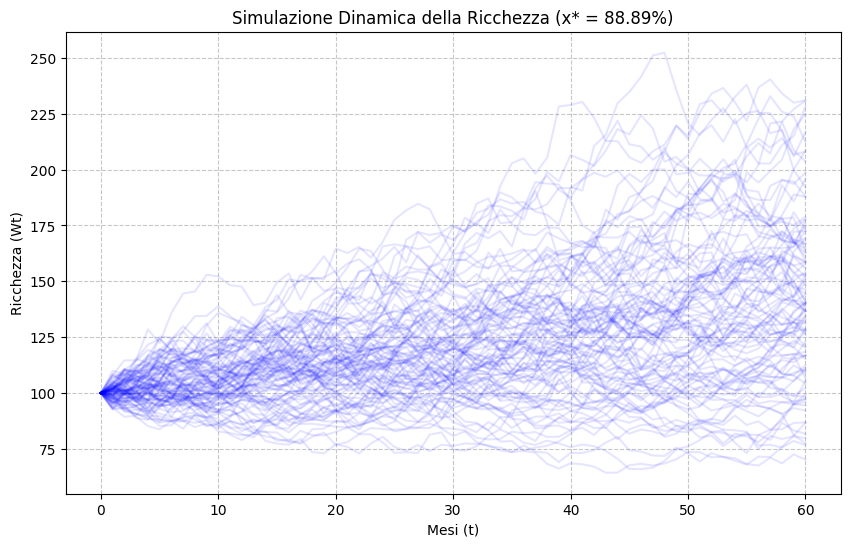

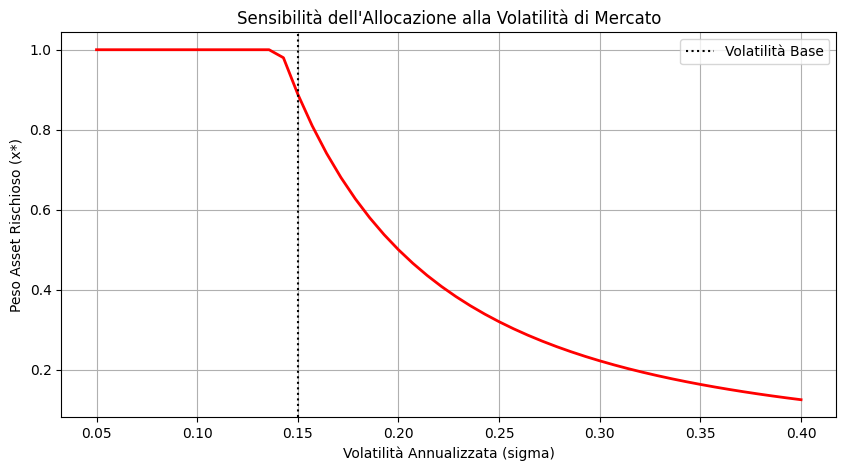

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class MertonPortfolioOptimizer:
    """
    Implementazione del modello di allocazione basato sull'utilità CRRA
    e la quota di Merton per la gestione dinamica del portafoglio.
    """
    def __init__(self, mu, rf, sigma, gamma, periods=12, initial_wealth=100):
        self.mu = mu              # Rendimento atteso annualizzato
        self.rf = rf              # Tasso risk-free annualizzato
        self.sigma = sigma        # Volatilità annualizzata
        self.gamma = gamma        # Coefficiente di avversione al rischio
        self.periods = periods    # Orizzonte temporale (es. mesi)
        self.initial_wealth = initial_wealth

    def calculate_optimal_weight(self, max_leverage=1.0, allow_short=False):
        """
        Calcola x* applicando i vincoli di ottimizzazione (Eq. 4.5).
        """
        # Formula core: x* = (1/gamma) * (mu - rf) / sigma^2
        excess_return = self.mu - self.rf
        variance = self.sigma ** 2
        x_star = (1 / self.gamma) * (excess_return / variance)

        # Applicazione vincoli
        if not allow_short:
            x_star = max(0, x_star)

        x_star = min(x_star, max_leverage)

        return x_star

    def simulate_wealth_path(self, seed=None):
        """
        Simula la dinamica della ricchezza W_t+1 = W_t(1 + rp,t+1)
        """
        if seed: np.random.seed(seed)

        x_star = self.calculate_optimal_weight()

        # Generazione rendimenti casuali log-normali per l'asset rischioso
        dt = 1 / 12  # Passo temporale mensile
        risky_returns = np.random.normal(
            (self.mu - 0.5 * self.sigma**2) * dt,
            self.sigma * np.sqrt(dt),
            self.periods
        )
        risky_returns = np.exp(risky_returns) - 1
        rf_periodic = self.rf * dt

        # Calcolo rendimento di portafoglio: rp = x* * r_risky + (1-x*) * rf
        portfolio_returns = x_star * risky_returns + (1 - x_star) * rf_periodic

        # Evoluzione della ricchezza
        wealth_path = [self.initial_wealth]
        for r in portfolio_returns:
            wealth_path.append(wealth_path[-1] * (1 + r))

        return np.array(wealth_path)

# --- CONFIGURAZIONE PARAMETRI ---
params = {
    'mu': 0.08,        # 8% Rendimento atteso
    'rf': 0.02,        # 2% Risk-free
    'sigma': 0.15,     # 15% Volatilità
    'gamma': 3.0,      # Avversione al rischio
    'periods': 60      # 5 anni (60 mesi)
}

optimizer = MertonPortfolioOptimizer(**params)
x_opt = optimizer.calculate_optimal_weight()

print(f"Allocazione Ottimale (x*): {x_opt:.2%}")
print(f"Allocazione Cash (1-x*): {1-x_opt:.2%}")

# --- SIMULAZIONE MONTE CARLO ---
n_simulations = 100
plt.figure(figsize=(10, 6))

for i in range(n_simulations):
    path = optimizer.simulate_wealth_path()
    plt.plot(path, color='blue', alpha=0.1)

plt.title(f"Simulazione Dinamica della Ricchezza (x* = {x_opt:.2%})")
plt.xlabel("Mesi (t)")
plt.ylabel("Ricchezza (Wt)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- ANALISI DI SENSIBILITÀ (STRESS TEST) ---
vol_range = np.linspace(0.05, 0.40, 50)
weights = []

for v in vol_range:
    optimizer.sigma = v
    weights.append(optimizer.calculate_optimal_weight())

plt.figure(figsize=(10, 5))
plt.plot(vol_range, weights, color='red', lw=2)
plt.title("Sensibilità dell'Allocazione alla Volatilità di Mercato")
plt.xlabel("Volatilità Annualizzata (sigma)")
plt.ylabel("Peso Asset Rischioso (x*)")
plt.axvline(x=0.15, color='black', linestyle=':', label='Volatilità Base')
plt.legend()
plt.grid(True)
plt.show()

## Quando si usa?

Il modello di allocazione basato sull'utilità CRRA (Constant Relative Risk Aversion) e la formula della quota di Merton vengono utilizzati principalmente in contesti di **Asset Management quantitativo** e **Pianificazione Finanziaria**.

Le situazioni specifiche in cui si applica questo modello sono:

### 1. Definizione dell'Asset Allocation Strategica (SAA)

Viene utilizzato per determinare la ripartizione "di base" tra classi di attività rischiose (come azioni) e attività prive di rischio (come titoli di stato a breve termine o liquidità). È il punto di partenza per costruire un portafoglio che rispetti la tolleranza al rischio specifica di un investitore o di un mandato di gestione.

### 2. Gestione di Portafogli a Volatilità Target (Target Volatility)

Poiché la formula include la varianza ($\sigma^2$) al denominatore, il modello è fondamentale per le strategie che mirano a mantenere costante il rischio. Quando la volatilità di mercato aumenta, il modello impone una riduzione automatica dell'esposizione ($x^*$) per mantenere il profilo di rischio del portafoglio entro i limiti stabiliti.

### 3. Risk Budgeting

Il modello serve a tradurre un obiettivo psicologico o normativo (l'avversione al rischio $\gamma$) in un limite numerico operativo. Permette a un gestore di rispondere alla domanda: "Data la mia massima perdita tollerabile e le attuali condizioni di mercato, quanto capitale posso permettermi di esporre al rischio oggi?".

### 4. Strategie di Investimento Dinamiche (Life-Cycle Funds)

Nel contesto dell'investimento per il lungo periodo (come i fondi pensione), il modello viene utilizzato per aggiustare il portafoglio man mano che l'orizzonte temporale $T$ si accorcia o le passività cambiano. Come indicato nel testo, permette di ricalcolare i pesi ottimali a ogni intervallo $t$ in base al variare della ricchezza accumulata.

### 5. Benchmark Teorico per l'Ottimizzazione Media-Varianza

Viene impiegato come "test di realtà" per modelli di ottimizzazione più complessi. Essendo una soluzione analitica elegante e semplice, fornisce un valore di riferimento per verificare se modelli più sofisticati (che includono più asset o vincoli complessi) stiano producendo risultati sensati o se stiano introducendo un errore di stima eccessivo.

### 6. Analisi di Scenario e Stress Testing

Il modello è utile per simulare come dovrebbe cambiare il portafoglio in presenza di regimi di mercato differenti. Ad esempio, permette di quantificare la necessità di deleveraging (riduzione della leva) in caso di un improvviso aumento della volatilità o di una riduzione del premio per il rischio atteso.

**In sintesi:** si utilizza ogni volta che è necessario stabilire una connessione rigorosa e matematica tra le **aspettative di rendimento**, la **rischiosità del mercato** e la **capacità di assorbimento del rischio** dell'investitore.